In [1]:
from qaoa_old import * 
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

In [10]:

def plot_graph(graph):
    """
    Plot the graph using networkx and matplotlib.

    Args:
    - graph (list of lists): The adjacency matrix representing the graph.
    """

    G = nx.Graph()

    # Add nodes
    num_vertices = len(graph)
    for i in range(num_vertices):
        G.add_node(i + 1)

    # Add edges
    for i in range(num_vertices):
        for j in range(i + 1, num_vertices):
            if graph[i][j] == 1:
                G.add_edge(i + 1, j + 1)

    # Plot graph
    pos = nx.spring_layout(G)  # positions for all nodes
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, font_size=10)
    plt.title("Graph for Max-Cut Problem")
    plt.show()

def plot_multiple_angles_on_circle(angles_list, alpha=0.1):
    """
    Plot optimal angles as dots on a circle for betas and gammas with different colors for multiple angle arrays.

    Args:
    - angles_list (list of arrays): List of optimal angle arrays for betas and gammas.

    Returns:
    - None
    """
    num_betas = len(angles_list[0]) // 2  # Assuming all arrays have the same length
    num_runs = len(angles_list)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location('N')
    ax.set_aspect('equal')

    radius = [0.5 + 0.2*i for i in range(num_betas)]
    for angles in angles_list:
        betas = angles[:num_betas]
        gammas = angles[num_betas:]
        for i, r in enumerate(radius):
            # Plot betas with reduced transparency
            ax.plot(betas[i], r, 'bo', markersize=8, alpha=alpha)

            # Plot gammas with reduced transparency
            ax.plot(gammas[i], r, 'ro', markersize=8, alpha=alpha)

    plt.title("Optimal Angles on Circle")
    ax.set_yticks([0.5 + 0.2*i for i in range(num_betas)])
    ax.set_yticklabels([i+1 for i in range(num_betas)])
    plt.show()



In [6]:
edges = []
for i in range(9):
    edges.append([i,i+1])
edges.append([9,0])
for i in range(8):
    edges.append([i,i+2])
edges.append([9,1])
edges.append([8,0])

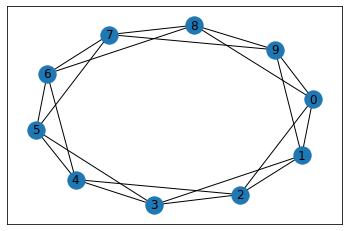

In [7]:
G = nx.from_edgelist(edges)
nx.draw_networkx(G)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
hamiltonian = Graph_to_Hamiltonian(adj_matrix)

In [9]:
angles_list = []
for i in tqdm(range(100)):
    q = QAOA(10, hamiltonian)
    q.run_heuristic_LW()
    if q.q_error < 0.1:
        angles_list.append(q.opt_angles)


100%|██████████| 100/100 [1:00:15<00:00, 36.15s/it]


NameError: name 'plot_multiple_angles_on_circle' is not defined

In [22]:
np.save('./angles_conc/rings',angles_list)

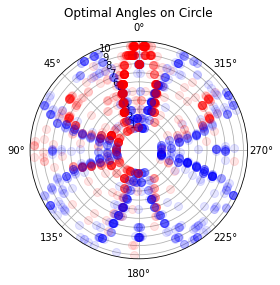

In [11]:
plot_multiple_angles_on_circle(angles_list)

In [34]:
q = QAOA(4, hamiltonian)
real_min = np.array([2,2,1,1,1,1,2,2])/8 * np.pi
q.expectation(real_min)

0.4180908203125

In [36]:
q.run_heuristic_LW()

In [37]:
q.opt_angles

array([3.42212309, 1.47089262, 5.20039104, 2.60216086, 2.11355515,
       1.99866294, 6.10036706, 0.19608802])

In [38]:
q.q_energy

-7.13182483889023